In [ ]:
from openbb import obb
gdp = obb.economy.gdp.nominal(units='capita', country='all', frequency='annual')
df = gdp.to_dataframe()

In [ ]:
df


,country,value
date,,
2020-01-01,Luxembourg,121923.7
2020-01-01,Ireland,97780.6
2020-01-01,Switzerland,74331.5
2020-01-01,Norway,67129.0
2020-01-01,United States,64414.5
...,...,...
2024-01-01,Bulgaria,41519.4
2024-01-01,Chile,34083.5
2024-01-01,Costa Rica,29055.1


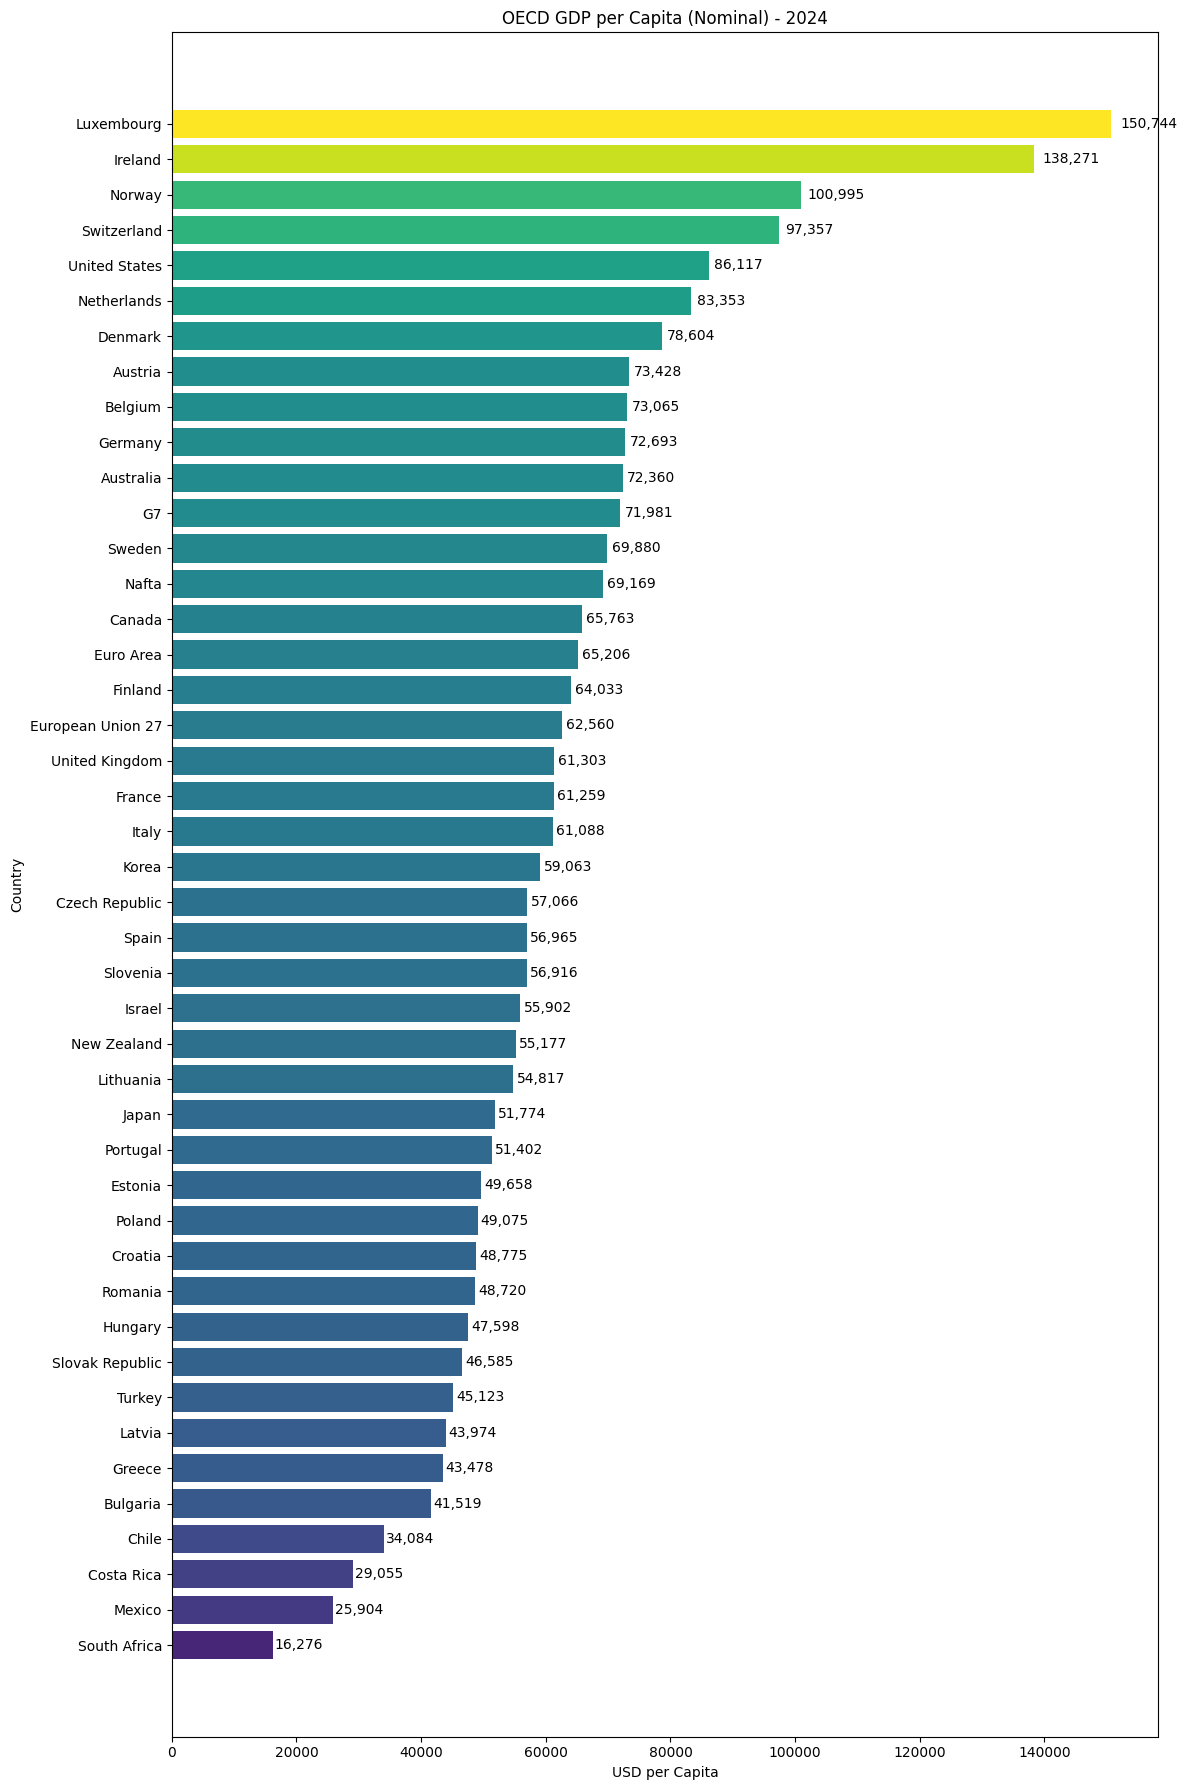

In [70]:
import matplotlib.pyplot as plt

latest_year = df.index.max()

# Filter for the latest year and sort
latest_gdp = df[df.index == latest_year].sort_values('value', ascending=False)

# Create horizontal bar chart
plt.figure(figsize=(12, 18))
bars = plt.barh(latest_gdp['country'], latest_gdp['value'], 
                color=plt.cm.viridis(latest_gdp['value']/max(latest_gdp['value'])))

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01, bar.get_y() + bar.get_height()/2, 
             f'{width:,.0f}', 
             va='center', ha='left')

plt.title(f'OECD GDP per Capita (Nominal) - {latest_year.year}')
plt.xlabel('USD per Capita')
plt.ylabel('Country')
plt.gca().invert_yaxis()  # Highest GDP at top
plt.tight_layout()
plt.show()


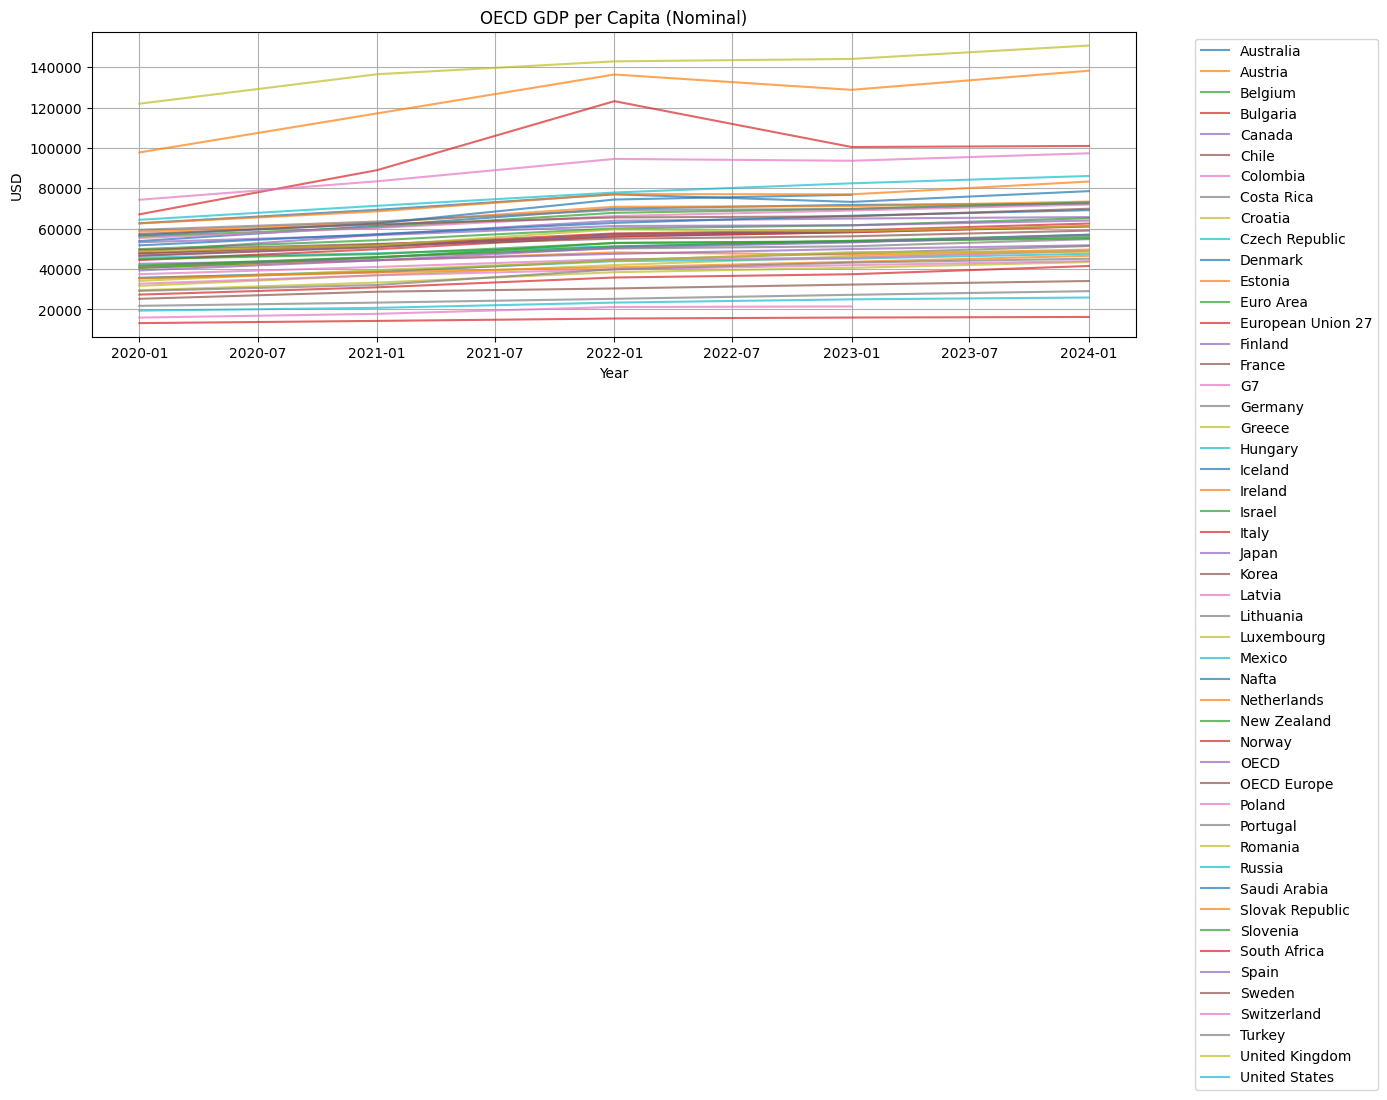

In [ ]:
import matplotlib.pyplot as plt

df = gdp.to_dataframe()
# Pivot data for plotting
pivot_gdp = df.pivot(columns='country', values='value')

# Create plot
plt.figure(figsize=(14, 8))
for country in pivot_gdp.columns:
    plt.plot(pivot_gdp.index, pivot_gdp[country], label=country, alpha=0.7)

plt.title('OECD GDP per Capita (Nominal)')
plt.xlabel('Year')
plt.ylabel('USD')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
